# Credit Risk Prediction Pipeline

This notebook contains the **Exploratory Data Analysis (EDA)** and **Data Cleaning** steps for the Credit Risk Prediction project. The goal is to analyze customer financial behaviors and prepare the dataset for Machine Learning models.

## 1. Data Loading & Initial Inspection
In this section, we load the dataset and check the first few rows to understand the structure of the financial features.

In [2]:
import pandas as pd
df = pd.read_csv('../data/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 🔍 Initial Observations & Anomalies
* **Data Structure:** The dataset contains customer demographics (age, income) and loan details (amount, interest rate).
* **Target Variable:** `loan_status` where `0` represents non-default (safe) and `1` represents default (risky) customers.
* **Outlier Alert:** In the first 5 rows, we can clearly observe that `person_emp_length` has an anomalous value of **123.0 years**, which is biologically and logically impossible. We need to perform a deeper outlier analysis.

## 2. Statistical Summary & Missing Value Analysis
We will now look at the descriptive statistics of numerical variables to detect further outliers and check for missing (null) values across columns.

In [3]:
# Sayısal Değişkenlerin Özeti (Uç değerleri yakalamak için)
print("--- Statistical Summary of Numerical Features ---")
display(df.describe())

print("\n" + "="*50 + "\n")

# Eksik verileri analiz edeceğiz
print("--- Missing Value Counts ---")
print(df.isnull().sum())

--- Statistical Summary of Numerical Features ---


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000




--- Missing Value Counts ---
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


## 3. Data Cleaning & Outlier Handling

Based on the statistical summary, we identified critical anomalies and missing values that must be handled before moving to modeling:

### Found Anomalies:
1. **Age Outlier:** Maximum age is detected as **144 years**, which is biologically impossible.
2. **Employment Length Outlier:** Maximum employment length is **123 years**, which is logically impossible.

### Missing Values:
* `person_emp_length` and `loan_int_rate` contain missing records.

### Strategy:
* We will filter out records where `person_age > 100` and `person_emp_length > 60` (or greater than age).
* Missing values for employment length will be filled using the **median** value to avoid skewness, and interest rates will be handled similarly or dropped depending on banking risk impact.

In [4]:
# 1. Anomalileri (Outliers) filtreleyerek veri setinden temizleyelim
# Yaşı 100'den küçük olan ve çalışma süresi 60 yıldan az olan mantıklı kayıtları tutuyoruz
df_clean = df[(df['person_age'] < 100) & (df['person_emp_length'] < 60)].copy()

# 2. Eksik değerleri (Missing Values) dolduralım
# Çalışma süresindeki boşlukları medyan (orta değer) ile dolduruyoruz
emp_median = df_clean['person_emp_length'].median()
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(emp_median)

# Faiz oranındaki boşlukları da yine veriyi bozmamak adına medyan ile dolduralım
int_median = df_clean['loan_int_rate'].median()
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(int_median)

# 3. Temizlik sonrası yeni maksimum değerleri ve eksik veri durumunu kontrol edelim
print(f"Temizlik Öncesi Satır Sayısı: {df.shape[0]}")
print(f"Temizlik Sonrası Satır Sayısı: {df_clean.shape[0]}")
print("-" * 50)
print("Yeni Maksimum Değerler:")
print(f"Maksimum Yaş: {df_clean['person_age'].max()}")
print(f"Maksimum Çalışma Süresi: {df_clean['person_emp_length'].max()}")
print("-" * 50)
print("Kalan Eksik Veri Sayısı:")
print(df_clean.isnull().sum())

Temizlik Öncesi Satır Sayısı: 32581
Temizlik Sonrası Satır Sayısı: 31679
--------------------------------------------------
Yeni Maksimum Değerler:
Maksimum Yaş: 94
Maksimum Çalışma Süresi: 41.0
--------------------------------------------------
Kalan Eksik Veri Sayısı:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## 4. Categorical Feature Encoding
Machine learning models require numerical inputs. We will transform our categorical variables (`person_home_ownership`, `loan_intent`, `loan_grade`, and `cb_person_default_on_file`) into numerical format using **One-Hot Encoding** (`pd.get_dummies`).

In [5]:
# One-Hot Encoding uygulanacak kategorik kolonları seçelim
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# pandas get_dummies fonksiyonu ile kategorik verileri 0 ve 1'lere dönüştürüyoruz
# drop_first=True yaparak 'dummy variable trap' (kukla değişken tuzağı) durumunu engelliyoruz
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Yeni veri setimizin ilk 5 satırına ve dönüştürülen kolonlara göz atalım
print(f"Dönüşüm Sonrası Yeni Veri Seti Boyutu: {df_encoded.shape}")
print("-" * 50)
display(df_encoded.head())

Dönüşüm Sonrası Yeni Veri Seti Boyutu: (31679, 23)
--------------------------------------------------


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
5,21,9900,2.0,2500,7.14,1,0.25,2,False,True,...,False,False,True,False,False,False,False,False,False,False


## 5. Train-Test Split
To evaluate our machine learning model objectively, we split the dataset into training (80%) and testing (20%) sets. We use `stratify=y` to ensure that the proportion of defaulted vs. non-defaulted loans remains consistent across both subsets, which is crucial for handling imbalanced financial datasets.

In [6]:
from sklearn.model_selection import train_test_split

# 1. Hedef değişkeni (y) ve bağımsız değişkenleri (X) ayıralım
# loan_status bizim tahmin etmek istediğimiz target kolonumuz
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status']

# 2. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Bölme işlemi sonrası boyutları kontrol edelim
print(f"Eğitim Verisi Boyutu (X_train): {X_train.shape}")
print(f"Test Verisi Boyutu (X_test): {X_test.shape}")
print("-" * 50)
print("Eğitim Setindeki Risk Oranı (Target Distribution):")
print(y_train.value_counts(normalize=True))

Eğitim Verisi Boyutu (X_train): (25343, 22)
Test Verisi Boyutu (X_test): (6336, 22)
--------------------------------------------------
Eğitim Setindeki Risk Oranı (Target Distribution):
loan_status
0    0.784556
1    0.215444
Name: proportion, dtype: float64


## 6. Model Training with XGBoost
We chose **XGBoost** because it is an industry-standard gradient boosting algorithm that provides exceptional performance on tabular financial data, dealing robustness with non-linear relationships.

In [9]:
import sys
!{sys.executable} -m pip install xgboost scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. XGBoost modelini tanımlayalım
# Finansal verilerde dengesizliği yönetmesi için temel parametrelerle başlatıyoruz
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2. Modeli eğitim verilerimizle eğitelim
model_xgb.fit(X_train, y_train)

# 3. Test verisi üzerinde tahminlerimizi yapalım
y_pred = model_xgb.predict(X_test)

# 4. İlk performans raporunu yazdıralım
print("--- XGBoost Model Performance Report ---")
print(classification_report(y_test, y_pred))

c:\Users\micon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:56:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Model Performance Report ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4971
           1       0.97      0.73      0.84      1365

    accuracy                           0.94      6336
   macro avg       0.95      0.86      0.90      6336
weighted avg       0.94      0.94      0.93      6336



## 7. Feature Importance Analysis
To make our XGBoost model explainable for bank stakeholders, we visualize the feature importance weights. This helps us understand which financial or demographic factors contribute most to the credit default risk.

In [14]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 9.0 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.5 MB 9.9 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 10.6 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 10.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 11.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------- -------------------------- 2.4/7.2 MB 11.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.0/7.2 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 11.0 MB/s  0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [p

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.
C:\Users\micon\AppData\Local\Temp\ipykernel_115336\1781927954.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


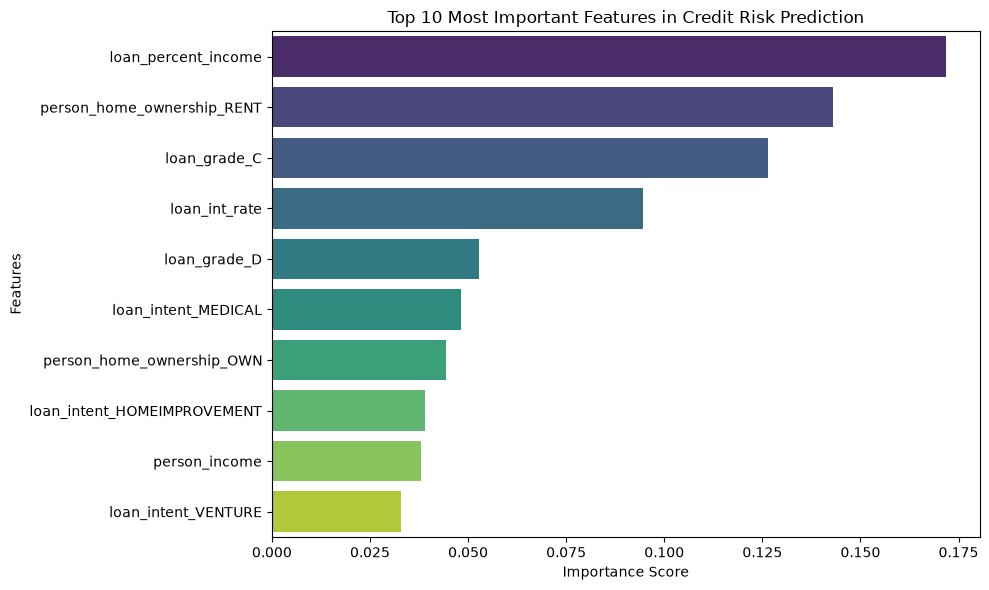

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Modelin özellik önem derecelerini alıp bir DataFrame oluşturalım
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. En önemli ilk 10 özelliği grafik olarak çizdirelim
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features in Credit Risk Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()